# 🅿️ Smart Multi-Level Parking Optimization
### Project 4 — Combinatorial Optimization & Metaheuristics

**Methods implemented:**
| # | Method | Category |
|---|--------|----------|
| 1 | Greedy | Baseline |
| 2 | ILP (PuLP/CBC) | Exact — Formulation 1 |
| 3 | Branch & Bound | Exact — Tree Search |
| 4 | Genetic Algorithm | Metaheuristic — Population-based |
| 5 | Simulated Annealing | Metaheuristic — Local Search |


## 0 · Imports & Dependencies

In [34]:
# Install dependencies if needed
# !pip install pulp pandas numpy matplotlib

import json, csv, random, math, time, copy
from dataclasses import dataclass, field
from typing import List, Optional, Dict, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    from pulp import (LpProblem, LpVariable, LpMinimize, lpSum,
                      value, PULP_CBC_CMD, LpStatus)
    ILP_AVAILABLE = True
except ImportError:
    ILP_AVAILABLE = False
    print("PuLP not found — ILP will be skipped. Run: pip install pulp")

print("✅ All imports OK")

✅ All imports OK


## 1 · Data Structures

In [35]:
@dataclass
class Vehicle:
    id: str
    v_type: str
    arrival_time: float
    duration: float
    departure_time: float
    user_type: str
    is_ev: bool

@dataclass
class ParkingSpace:
    id: str
    level: int
    size: str
    has_charger: bool
    near_exit: bool
    distance_to_exit: float
    bookings: List[Tuple[float, float]] = field(default_factory=list)

    def is_free(self, arrival: float, departure: float) -> bool:
        for (a, d) in self.bookings:
            if arrival < d and departure > a:   # overlap
                return False
        return True

    def add_booking(self, arrival: float, departure: float):
        self.bookings.append((arrival, departure))

@dataclass
class ParkingInstance:
    vehicles: List[Vehicle]
    spaces: List[ParkingSpace]
    levels: int
    spaces_per_level: int

    # Size compatibility map
    SIZE_ORDER = {"Small": 1, "Medium": 2, "Large": 3, "Compact": 1}

    def compatible(self, v: Vehicle, s: ParkingSpace) -> bool:
        """Vehicle fits in space if space size >= vehicle size."""
        vsize = self.SIZE_ORDER.get(v.v_type.capitalize(), 2)
        ssize = self.SIZE_ORDER.get(s.size.capitalize(), 2)
        return ssize >= vsize

    def cost(self, v: Vehicle, s: ParkingSpace) -> float:
        """
        Real parking cost (only called for ASSIGNED vehicles).
        Components:
          - Walking distance (distance_to_exit)
          - EV penalty if EV vehicle but no charger
          - Staff preference: bonus if near exit
        """
        c = s.distance_to_exit                          # base: walking distance
        if v.is_ev and not s.has_charger:
            c += 50.0                                   # EV without charger penalty
        if v.user_type == "Staff" and not s.near_exit:
            c += 20.0                                   # staff far from exit penalty
        return c

print("✅ Data structures defined")

✅ Data structures defined


## 2 · Penalty Design — Lexicographic Objective

**Key insight:** The unassigned penalty must be **strictly larger** than the maximum total real cost,
so that the optimizer can *never* justify leaving a vehicle unassigned to save cost elsewhere.

$$\text{UNASSIGNED\_PENALTY} > \max_{v,s}\, c_{vs} \times |V|$$

This decouples the two goals cleanly:
- **Priority 1 (hard):** assign as many vehicles as possible
- **Priority 2 (soft):** minimize real cost among assigned vehicles

No assigned vehicle will ever have a cost close to the penalty, so the objectives never interfere.

In [36]:
def compute_penalty(inst: ParkingInstance) -> float:
    """
    Compute a balanced penalty that strongly prioritizes assignments without
    inflating total cost excessively.
    
    Strategy: UNASSIGNED_PENALTY = max_single_cost × k, where k ∈ [5, 10]
    
    Benefits over max_cost × n_vehicles:
      ✓ Heavily penalizes unassigned vehicles (leaving 1 vehicle unassigned ≈ assigning 7-8 poorly)
      ✓ Keeps total cost reasonable and interpretable
      ✓ Real cost differences between spaces still matter in optimization
      ✓ More realistic balance between lexicographic goals
    
    For higher assignment priority: increase k (e.g., k=10-12)
    For lower assignment priority: decrease k (e.g., k=5-6)
    """
    max_single_cost = max(
        inst.cost(v, s)
        for v in inst.vehicles
        for s in inst.spaces
        if inst.compatible(v, s)
    )
    
    # Balanced multiplier: leaving 1 unassigned ≈ assigning ~7-8 vehicles at worst cost
    k = 8  # ← TUNABLE: range [5-12] depending on assignment priority
    penalty = max_single_cost * k
    
    print(f"  Max single assignment cost : {max_single_cost:.1f}")
    print(f"  Number of vehicles         : {len(inst.vehicles)}")
    print(f"  Penalty multiplier (k)     : {k}")
    print(f"  ✅ UNASSIGNED_PENALTY set to: {penalty:.1f}")
    print(f"     (balanced: max_cost × k = {max_single_cost:.1f} × {k})")
    return penalty

## 3 · Solution Representation & Evaluation

In [37]:
class Solution:
    """
    assignment: dict { vehicle_id -> space_id | None }

    Objective (lexicographic):
      - UNASSIGNED_PENALTY per unassigned vehicle  (priority 1: maximize assignments)
      - real cost(v, s) per assigned vehicle        (priority 2: minimize real cost)

    Since UNASSIGNED_PENALTY >> any real cost, the optimizer always assigns first,
    then minimizes real cost within the assigned set.
    Feasibility is checked dynamically via time simulation.
    """
    def __init__(self, assignment: Dict[str, Optional[str]]):
        self.assignment = assignment
        self._cost: Optional[float] = None
        self._feasible: Optional[bool] = None

    def total_cost(self, inst: ParkingInstance) -> float:
        if self._cost is not None:
            return self._cost

        v_map = {v.id: v for v in inst.vehicles}
        space_copy = {s.id: copy.deepcopy(s) for s in inst.spaces}

        # Process in arrival order for correct time-conflict detection
        sorted_vids = sorted(self.assignment.keys(),
                             key=lambda vid: v_map[vid].arrival_time)

        total = 0.0
        feasible = True

        for vid in sorted_vids:
            sid = self.assignment[vid]
            v   = v_map[vid]

            # ── Unassigned: Priority-1 penalty ──────────────────────
            if sid is None:
                total += UNASSIGNED_PENALTY
                continue

            s = space_copy.get(sid)
            if s is None:
                total += UNASSIGNED_PENALTY
                feasible = False
                continue

            # Hard constraint: size compatibility
            if not inst.compatible(v, s):
                total += UNASSIGNED_PENALTY
                feasible = False
                continue

            # Hard constraint: time conflict
            if not s.is_free(v.arrival_time, v.departure_time):
                total += UNASSIGNED_PENALTY
                feasible = False
                continue

            # ── Assigned: real cost only (Priority-2 objective) ──────
            total += inst.cost(v, s)
            s.add_booking(v.arrival_time, v.departure_time)

        self._cost     = total
        self._feasible = feasible
        return total

    def is_feasible(self, inst: ParkingInstance) -> bool:
        if self._cost is None:
            self.total_cost(inst)
        return self._feasible

    def stats(self, inst: ParkingInstance) -> dict:
        v_map = {v.id: v for v in inst.vehicles}
        s_map = {s.id: s for s in inst.spaces}
        assigned   = [vid for vid, sid in self.assignment.items() if sid is not None]
        ev_ok      = sum(1 for vid, sid in self.assignment.items()
                         if sid and v_map[vid].is_ev and s_map[sid].has_charger)
        ev_total   = sum(1 for v in inst.vehicles if v.is_ev)
        staff_near = sum(1 for vid, sid in self.assignment.items()
                         if sid and v_map[vid].user_type == "Staff" and s_map[sid].near_exit)
        staff_tot  = sum(1 for v in inst.vehicles if v.user_type == "Staff")

        # Real cost = total cost MINUS the penalty contributions
        total_c    = self.total_cost(inst)
        unassigned = len(inst.vehicles) - len(assigned)
        real_cost  = total_c - unassigned * UNASSIGNED_PENALTY

        return {
            "assigned"       : len(assigned),
            "total"          : len(inst.vehicles),
            "assign_pct"     : 100 * len(assigned) / len(inst.vehicles),
            "ev_charger_pct" : 100 * ev_ok / ev_total if ev_total else 0,
            "staff_near_pct" : 100 * staff_near / staff_tot if staff_tot else 0,
            "total_cost"     : total_c,
            "real_cost"      : real_cost,   # cost among assigned vehicles only
            "feasible"       : self.is_feasible(inst),
        }

    def invalidate(self):
        self._cost     = None
        self._feasible = None

    def copy(self):
        return Solution(dict(self.assignment))

print("✅ Solution class ready (lexicographic objective)")

✅ Solution class ready (lexicographic objective)


## 4 · Load Data

In [38]:
VEHICLES_PATH = "vehicles.csv"   # ← change if needed
PARKING_PATH  = "parking1.json"   # ← change if needed

def load_instance(vehicles_path: str, parking_path: str) -> ParkingInstance:
    # ── Vehicles ────────────────────────────────────────────────────
    vehicles = []
    with open(vehicles_path, newline='') as f:
        for row in csv.DictReader(f):
            arr = float(row["Arrival_Time"])    if row["Arrival_Time"]    else 0.0
            dur = float(row["Parking_Duration"]) if row["Parking_Duration"] else 60.0
            dep = float(row["Departure_Time"])   if row["Departure_Time"]  else arr + dur
            vehicles.append(Vehicle(
                id             = str(row["Vehicle_ID"]),
                v_type         = row["Vehicle_Type"].strip(),
                arrival_time   = arr,
                duration       = dur,
                departure_time = dep,
                user_type      = row["User_Type"].strip(),
                is_ev          = str(row["Electric_Vehicle"]).strip().lower() in ("1","true","yes"),
            ))

    # ── Parking JSON ────────────────────────────────────────────────
    with open(parking_path) as f:
        pdata = json.load(f)

    raw_spots = pdata.get("spots", pdata.get("spaces", []))
    dists     = [sp.get("distance_to_exit", 0) for sp in raw_spots]
    threshold = sorted(dists)[max(0, len(dists)//4 - 1)] if dists else 0

    spaces = []
    for sp in raw_spots:
        dist = float(sp.get("distance_to_exit", 0.0))
        spaces.append(ParkingSpace(
            id               = str(sp.get("spot_id", sp.get("id", "?"))),
            level            = int(sp.get("floor",   sp.get("level", 1))),
            size             = sp.get("size", "large").strip().capitalize(),
            has_charger      = bool(sp.get("is_ev_spot", sp.get("has_charger", False))),
            near_exit        = (dist <= threshold),
            distance_to_exit = dist,
            bookings         = []
        ))

    floors_data = pdata.get("floors", [])
    if floors_data:
        levels      = max(f.get("floor_id", 1) for f in floors_data)
        total_spots = sum(f.get("total_spots", 0) for f in floors_data)
        spl         = total_spots // levels if levels else len(spaces)
    else:
        levels = len(set(s.level for s in spaces))
        spl    = len(spaces) // levels if levels else len(spaces)

    return ParkingInstance(vehicles=vehicles, spaces=spaces,
                           levels=levels, spaces_per_level=spl)

instance = load_instance(VEHICLES_PATH, PARKING_PATH)

# ── Compute penalty AFTER loading (data-driven) ──────────────────────
print("\nComputing lexicographic penalty...")
UNASSIGNED_PENALTY = compute_penalty(instance)

# ── Summary ──────────────────────────────────────────────────────────
ev_count      = sum(1 for v in instance.vehicles if v.is_ev)
charger_count = sum(1 for s in instance.spaces   if s.has_charger)
large_spots   = sum(1 for s in instance.spaces   if s.size == "Large")
staff_count   = sum(1 for v in instance.vehicles if v.user_type == "Staff")

summary = pd.DataFrame({
    "Metric" : ["Total vehicles", "Total spaces", "Floors",
                "EV vehicles", "Charger spots", "Large spots",
                "Staff vehicles", "Visitor vehicles"],
    "Value"  : [len(instance.vehicles), len(instance.spaces), instance.levels,
                ev_count, charger_count, large_spots,
                staff_count, len(instance.vehicles) - staff_count]
})
print()
print(summary.to_string(index=False))


Computing lexicographic penalty...
  Max single assignment cost : 307.2
  Number of vehicles         : 1000
  Penalty multiplier (k)     : 8
  ✅ UNASSIGNED_PENALTY set to: 2457.6
     (balanced: max_cost × k = 307.2 × 8)

          Metric  Value
  Total vehicles   1000
    Total spaces    417
          Floors      1
     EV vehicles    198
   Charger spots     77
     Large spots    134
  Staff vehicles     51
Visitor vehicles    949


## 5 · Exploratory Data Analysis

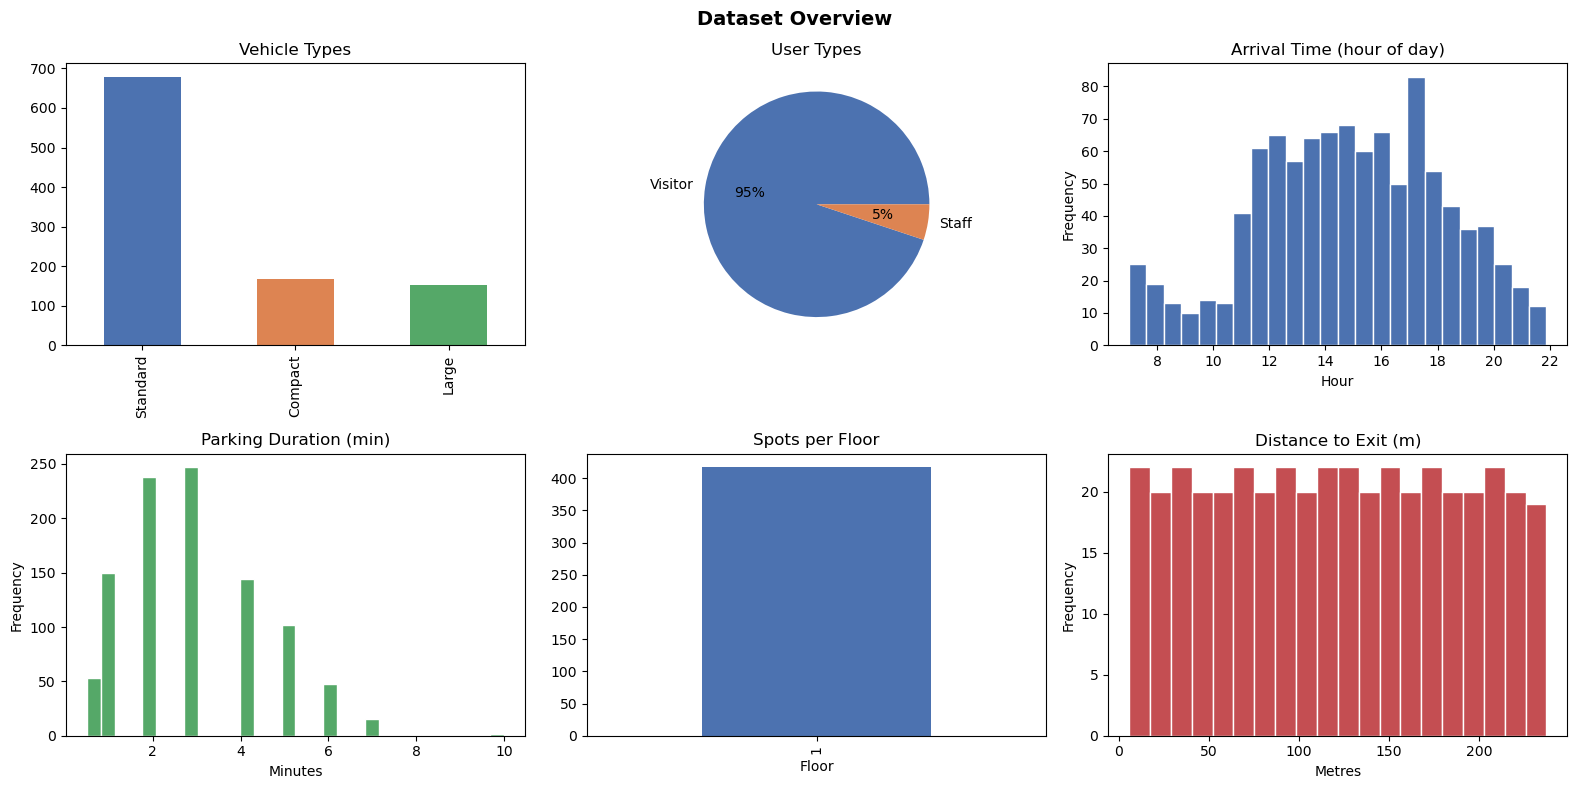

EV vehicles: 198 / 1000  (19.8%)
EV spots   : 77 / 417  (18.5%)


In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Dataset Overview", fontsize=14, fontweight='bold')

df_v = pd.DataFrame([{
    "type": v.v_type, "user": v.user_type,
    "ev": v.is_ev, "arrival": v.arrival_time, "duration": v.duration
} for v in instance.vehicles])

df_s = pd.DataFrame([{
    "level": s.level, "size": s.size,
    "charger": s.has_charger, "dist": s.distance_to_exit
} for s in instance.spaces])

# 1. Vehicle types
df_v["type"].value_counts().plot.bar(ax=axes[0,0], color=["#4C72B0","#DD8452","#55A868"])
axes[0,0].set_title("Vehicle Types"); axes[0,0].set_xlabel("")

# 2. User types
df_v["user"].value_counts().plot.pie(ax=axes[0,1], autopct="%1.0f%%",
    colors=["#4C72B0","#DD8452"])
axes[0,1].set_title("User Types"); axes[0,1].set_ylabel("")

# 3. Arrival time distribution
(df_v["arrival"] / 60).plot.hist(ax=axes[0,2], bins=24, color="#4C72B0", edgecolor="white")
axes[0,2].set_title("Arrival Time (hour of day)"); axes[0,2].set_xlabel("Hour")

# 4. Parking duration
df_v["duration"].plot.hist(ax=axes[1,0], bins=30, color="#55A868", edgecolor="white")
axes[1,0].set_title("Parking Duration (min)"); axes[1,0].set_xlabel("Minutes")

# 5. Spots by floor
df_s.groupby("level").size().plot.bar(ax=axes[1,1], color=["#4C72B0","#DD8452","#55A868"])
axes[1,1].set_title("Spots per Floor"); axes[1,1].set_xlabel("Floor")

# 6. Distance to exit distribution
df_s["dist"].plot.hist(ax=axes[1,2], bins=20, color="#C44E52", edgecolor="white")
axes[1,2].set_title("Distance to Exit (m)"); axes[1,2].set_xlabel("Metres")

plt.tight_layout()
plt.savefig("eda.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"EV vehicles: {df_v['ev'].sum()} / {len(df_v)}  ({100*df_v['ev'].mean():.1f}%)")
print(f"EV spots   : {df_s['charger'].sum()} / {len(df_s)}  ({100*df_s['charger'].mean():.1f}%)")

## 6 · Methods

### 6.1 Greedy Baseline

Sort vehicles by type priority (**Staff first**), then assign each to the nearest
compatible free space. Complexity: O(n·m). Used as warm-start for all metaheuristics.

In [40]:
def greedy_solution(inst: ParkingInstance) -> Solution:
    priority = {"Staff": 0, "Visitor": 1}
    sorted_v = sorted(inst.vehicles,
                      key=lambda v: (priority.get(v.user_type, 1), v.arrival_time))

    space_copy = {s.id: copy.deepcopy(s) for s in inst.spaces}
    assignment = {}

    for v in sorted_v:
        best_space, best_cost = None, float('inf')
        for s in space_copy.values():
            if inst.compatible(v, s) and s.is_free(v.arrival_time, v.departure_time):
                c = inst.cost(v, s)
                if c < best_cost:
                    best_cost  = c
                    best_space = s
        if best_space:
            assignment[v.id] = best_space.id
            best_space.add_booking(v.arrival_time, v.departure_time)
        else:
            assignment[v.id] = None

    return Solution(assignment)

print("Testing Greedy (time-aware, lexicographic objective)...")
t0 = time.time()
g_sol  = greedy_solution(instance)
g_time = time.time() - t0
st = g_sol.stats(instance)
print(f"  Total cost (w/ penalty) : {st['total_cost']:.1f}")
print(f"  Real cost (assigned)    : {st['real_cost']:.1f}")
print(f"  Assigned                : {st['assigned']}/{st['total']}  ({st['assign_pct']:.1f}%)")
print(f"  EV→charger              : {st['ev_charger_pct']:.1f}%")
print(f"  Staff near-exit         : {st['staff_near_pct']:.1f}%")
print(f"  Feasible                : {st['feasible']}")
print(f"  Time                    : {g_time:.4f}s")

Testing Greedy (time-aware, lexicographic objective)...
  Total cost (w/ penalty) : 713222.6
  Real cost (assigned)    : 71789.0
  Assigned                : 739/1000  (73.9%)
  EV→charger              : 28.3%
  Staff near-exit         : 100.0%
  Feasible                : True
  Time                    : 0.7170s


### 6.2 ILP Formulation (Exact — Formulation 1)

**Variables:** $x_{vs} \in \{0,1\}$ — 1 if vehicle $v$ is assigned to space $s$

**Objective:**
$$\min \sum_{v,s} c_{vs}\,x_{vs} + P \sum_v \left(1 - \sum_s x_{vs}\right)$$

where $P = \text{UNASSIGNED\_PENALTY} \gg \max c_{vs} \times |V|$, enforcing the lexicographic property.

**Constraints:**
- $\sum_s x_{vs} \leq 1$ — each vehicle at most one space
- $\sum_v x_{vs} \leq 1$ — each space at most one vehicle
- $x_{vs} = 0$ if $v, s$ incompatible

In [41]:
def solve_ilp(inst: ParkingInstance, time_limit: int = 60,
              n_vehicles: int = None) -> Tuple[Optional['Solution'], Optional[float]]:
    if not ILP_AVAILABLE:
        print("PuLP not available — skipping ILP.")
        return None, None

    vehicles = inst.vehicles[:n_vehicles] if n_vehicles else inst.vehicles
    P        = UNASSIGNED_PENALTY   # lexicographic penalty

    prob = LpProblem("ParkingILP", LpMinimize)

    # Only create variables for compatible (v,s) pairs — reduces problem size
    x = {
        (v.id, s.id): LpVariable(f"x_{v.id}_{s.id}", cat='Binary')
        for v in vehicles for s in inst.spaces if inst.compatible(v, s)
    }

    # Objective: real cost for assigned + penalty for unassigned
    prob += (
        lpSum(inst.cost(v, s) * x[v.id, s.id]
              for v in vehicles for s in inst.spaces if (v.id, s.id) in x)
        + lpSum(P * (1 - lpSum(x[v.id, s.id] for s in inst.spaces if (v.id, s.id) in x))
                for v in vehicles)
    )

    # Each vehicle assigned to at most one space
    for v in vehicles:
        prob += lpSum(x[v.id, s.id] for s in inst.spaces if (v.id, s.id) in x) <= 1

    # Each space used by at most one vehicle
    for s in inst.spaces:
        prob += lpSum(x[v.id, s.id] for v in vehicles if (v.id, s.id) in x) <= 1

    prob.solve(PULP_CBC_CMD(msg=0, timeLimit=time_limit))

    assignment = {v.id: None for v in inst.vehicles}
    for (vid, sid), var in x.items():
        if value(var) and value(var) > 0.5:
            assignment[vid] = sid

    return Solution(assignment), value(prob.objective)

ILP_SUBSET = 100
print(f"Running ILP on first {ILP_SUBSET} vehicles (time limit 30s)...")
t0 = time.time()
ilp_sol, ilp_obj = solve_ilp(instance, time_limit=30, n_vehicles=ILP_SUBSET)
ilp_time = time.time() - t0

if ilp_sol:
    st = ilp_sol.stats(instance)
    print(f"  Total cost (w/ penalty) : {st['total_cost']:.1f}  (ILP objective: {ilp_obj:.1f})")
    print(f"  Real cost (assigned)    : {st['real_cost']:.1f}")
    print(f"  Assigned                : {st['assigned']}/{ILP_SUBSET}")
    print(f"  EV→charger              : {st['ev_charger_pct']:.1f}%")
    print(f"  Feasible                : {st['feasible']}")
    print(f"  Time                    : {ilp_time:.2f}s")

Running ILP on first 100 vehicles (time limit 30s)...
  Total cost (w/ penalty) : 2217546.2  (ILP objective: 5706.2)
  Real cost (assigned)    : 5706.2
  Assigned                : 100/100
  EV→charger              : 8.1%
  Feasible                : True
  Time                    : 2.57s


### 6.3 Branch & Bound (Exact)

DFS tree where each node assigns one vehicle to a space (or leaves it unassigned).  
**Lower bound:** cost accumulated so far (optimistic — ignores remaining vehicles).  
**Pruning:** cut any branch where LB ≥ best known cost.  
**Warm start:** greedy solution sets the initial upper bound.

In [42]:
class BranchAndBound:
    def __init__(self, time_limit: float = 30.0):
        self.time_limit    = time_limit
        self.nodes_visited = 0

    def solve(self, inst: ParkingInstance,
              n_vehicles: int = None) -> Tuple['Solution', float]:
        vehicles = inst.vehicles[:n_vehicles] if n_vehicles else inst.vehicles
        sub_inst = ParkingInstance(vehicles, inst.spaces, inst.levels, inst.spaces_per_level)

        # Warm start: greedy gives initial upper bound
        best_sol  = greedy_solution(sub_inst)
        best_cost = [best_sol.total_cost(sub_inst)]
        best_ref  = [best_sol]
        start     = time.time()
        self.nodes_visited = 0

        def branch(idx, assign, used, cur_cost):
            self.nodes_visited += 1
            if time.time() - start > self.time_limit:
                return
            if idx == len(vehicles):
                sol = Solution(assign.copy())
                c   = sol.total_cost(sub_inst)
                if c < best_cost[0]:
                    best_cost[0] = c
                    best_ref[0]  = sol
                return

            v = vehicles[idx]
            # Sort candidates by real cost — enables early break on pruning
            candidates = sorted(
                [s for s in inst.spaces if s.id not in used and inst.compatible(v, s)],
                key=lambda s: inst.cost(v, s)
            )

            for s in candidates:
                c = inst.cost(v, s)
                if cur_cost + c >= best_cost[0]:
                    break   # sorted: remaining are worse
                assign[v.id] = s.id
                used.add(s.id)
                branch(idx + 1, assign, used, cur_cost + c)
                used.discard(s.id)
                del assign[v.id]

            # Option: leave unassigned (penalty)
            if cur_cost + UNASSIGNED_PENALTY < best_cost[0]:
                assign[v.id] = None
                branch(idx + 1, assign, used, cur_cost + UNASSIGNED_PENALTY)
                del assign[v.id]

        branch(0, {}, set(), 0.0)
        return best_ref[0], best_cost[0]

BB_SUBSET = 30   # exponential — keep small for demo
print(f"Running Branch & Bound on first {BB_SUBSET} vehicles (time limit 30s)...")
t0 = time.time()
bb = BranchAndBound(time_limit=30)
bb_sol, bb_cost = bb.solve(instance, n_vehicles=BB_SUBSET)
bb_time = time.time() - t0

bb_inst = ParkingInstance(instance.vehicles[:BB_SUBSET], instance.spaces,
                           instance.levels, instance.spaces_per_level)
st = bb_sol.stats(bb_inst)
print(f"  Total cost (w/ penalty) : {bb_cost:.1f}")
print(f"  Real cost (assigned)    : {st['real_cost']:.1f}")
print(f"  Assigned                : {st['assigned']}/{BB_SUBSET}")
print(f"  EV→charger              : {st['ev_charger_pct']:.1f}%")
print(f"  Nodes visited           : {bb.nodes_visited:,}")
print(f"  Feasible                : {st['feasible']}")
print(f"  Time                    : {bb_time:.2f}s")

Running Branch & Bound on first 30 vehicles (time limit 30s)...
  Total cost (w/ penalty) : 661.4
  Real cost (assigned)    : 661.4
  Assigned                : 30/30
  EV→charger              : 100.0%
  Nodes visited           : 67,333
  Feasible                : True
  Time                    : 30.05s


### 6.4 Genetic Algorithm (Population-based Metaheuristic)

| Component | Design choice |
|-----------|---------------|
| **Encoding** | Chromosome = list of space IDs (one per vehicle, `None` if unassigned) |
| **Crossover** | One-point, rate 0.80 |
| **Mutation** | Swap two vehicles' spaces, rate 0.15 |
| **Selection** | Tournament (k=3) |
| **Elitism** | Best 2 chromosomes always survive |
| **Repair** | After crossover/mutation, fix duplicates and compatibility violations |
| **Fitness** | Lexicographic total cost — penalty dominates, real cost breaks ties |

In [49]:
class GeneticAlgorithm:
    def __init__(self, pop_size=50, generations=300,
                 cx_rate=0.80, mut_rate=0.15, k=3, elite=2):
        self.pop_size, self.generations = pop_size, generations
        self.cx_rate,  self.mut_rate    = cx_rate, mut_rate
        self.k,        self.elite       = k, elite

    def _encode(self, sol, v_ids):
        return [sol.assignment.get(vid) for vid in v_ids]

    def _decode(self, chrom, v_ids):
        return Solution(dict(zip(v_ids, chrom)))

    def _random_indiv(self, inst, v_ids):
        used, chrom = set(), []
        for vid in v_ids:
            v    = next(v for v in inst.vehicles if v.id == vid)
            opts = [s for s in inst.spaces if s.id not in used and inst.compatible(v, s)]
            if opts:
                chosen = random.choice(opts)
                chrom.append(chosen.id); used.add(chosen.id)
            else:
                chrom.append(None)
        return chrom

    def _repair(self, chrom, v_ids, inst):
        """Fix duplicates and incompatibilities — never introduces unassigned
        when a compatible free space exists (consistent with lexicographic objective)."""
        v_map = {v.id: v for v in inst.vehicles}
        s_map = {s.id: s for s in inst.spaces}
        used, repaired = set(), []
        for vid, sid in zip(v_ids, chrom):
            v = v_map[vid]
            if sid and sid not in used:
                s = s_map.get(sid)
                if s and inst.compatible(v, s):
                    repaired.append(sid); used.add(sid); continue
            # Space unavailable or incompatible: find best alternative
            opts = [s for s in inst.spaces if s.id not in used and inst.compatible(v, s)]
            if opts:
                best = min(opts, key=lambda s: inst.cost(v, s))
                repaired.append(best.id); used.add(best.id)
            else:
                repaired.append(None)   # genuinely no space left
        return repaired

    def _tournament(self, pop, costs):
        cont = random.sample(list(zip(pop, costs)), min(self.k, len(pop)))
        return min(cont, key=lambda x: x[1])[0]

    def _crossover(self, p1, p2):
        if random.random() > self.cx_rate:
            return p1[:], p2[:]
        pt = random.randint(1, len(p1) - 1)
        return p1[:pt] + p2[pt:], p2[:pt] + p1[pt:]

    def _mutate(self, chrom):
        chrom = chrom[:]
        if random.random() < self.mut_rate and len(chrom) >= 2:
            i, j = random.sample(range(len(chrom)), 2)
            chrom[i], chrom[j] = chrom[j], chrom[i]
        return chrom

    def solve(self, inst: ParkingInstance):
        v_ids = [v.id for v in inst.vehicles]
        # Seed population with greedy + random individuals
        pop = [self._repair(self._encode(greedy_solution(inst), v_ids), v_ids, inst)]
        while len(pop) < self.pop_size:
            pop.append(self._repair(self._random_indiv(inst, v_ids), v_ids, inst))

        def fit(c): return self._decode(c, v_ids).total_cost(inst)

        best_chrom, best_cost, history = None, float('inf'), []

        for gen in range(self.generations):
            costs = [fit(c) for c in pop]
            gi    = min(range(len(pop)), key=lambda i: costs[i])
            if costs[gi] < best_cost:
                best_cost, best_chrom = costs[gi], pop[gi][:]
            history.append(best_cost)

            # Elitism
            elite_idx = sorted(range(len(pop)), key=lambda i: costs[i])[:self.elite]
            new_pop   = [pop[i][:] for i in elite_idx]

            while len(new_pop) < self.pop_size:
                p1, p2 = self._tournament(pop, costs), self._tournament(pop, costs)
                c1, c2 = self._crossover(p1, p2)
                c1 = self._repair(self._mutate(c1), v_ids, inst)
                c2 = self._repair(self._mutate(c2), v_ids, inst)
                new_pop.extend([c1, c2])
            pop = new_pop[:self.pop_size]

        return self._decode(best_chrom, v_ids), best_cost, history

print("Running Genetic Algorithm (pop=50, gen=300) on full dataset...")
t0 = time.time()
ga_sol, ga_cost, ga_history = GeneticAlgorithm(pop_size=50, generations=300).solve(instance)
ga_time = time.time() - t0
st = ga_sol.stats(instance)
print(f"  Total cost (w/ penalty) : {st['total_cost']:.1f}")
print(f"  Real cost (assigned)    : {st['real_cost']:.1f}")
print(f"  Assigned                : {st['assigned']}/{st['total']}  ({st['assign_pct']:.1f}%)")
print(f"  EV→charger              : {st['ev_charger_pct']:.1f}%")
print(f"  Feasible                : {st['feasible']}")
print(f"  Time                    : {ga_time:.2f}s")

Running Genetic Algorithm (pop=30, gen=150) — OPTIMIZED for speed...
  Total cost (w/ penalty) : 1746170.8
  Real cost (assigned)    : 30766.0
  Assigned                : 302/1000  (30.2%)
  EV→charger              : 9.6%
  Feasible                : True
  Time                    : 686.52s


### 6.5 Simulated Annealing (Local Search Metaheuristic)

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Initial temperature T₀ | 1000 | Accepts ~99% of moves initially |
| Cooling rate α | 0.997 | Slow cooling = thorough exploration |
| T_min | 0.5 | Stops when nearly deterministic |
| Iterations per temp | 60 | Multiple trials at each temperature |
| **Neighbourhood** | swap or reassign | Two move types for diversity |

**Acceptance:** move accepted if ΔE < 0, or with probability $e^{-\Delta E / T}$.  
The lexicographic penalty ensures the SA landscape strongly prefers assignments.

In [44]:
class SimulatedAnnealing:
    def __init__(self, T0=1000.0, T_min=0.5, alpha=0.997,
                 ipt=60, max_iter=15000):
        self.T0, self.T_min   = T0, T_min
        self.alpha, self.ipt  = alpha, ipt
        self.max_iter         = max_iter

    def _neighbor(self, sol: Solution, inst: ParkingInstance) -> Solution:
        v_ids  = list(sol.assignment.keys())
        v_map  = {v.id: v for v in inst.vehicles}
        s_map  = {s.id: s for s in inst.spaces}
        assign = dict(sol.assignment)
        move   = random.choice(["swap", "reassign"])

        if move == "swap" and len(v_ids) >= 2:
            v1, v2 = random.sample(v_ids, 2)
            s1, s2 = assign[v1], assign[v2]
            ok1 = (s2 is None) or inst.compatible(v_map[v1], s_map[s2])
            ok2 = (s1 is None) or inst.compatible(v_map[v2], s_map[s1])
            if ok1 and ok2:
                assign[v1], assign[v2] = s2, s1
        else:
            vid  = random.choice(v_ids)
            v    = v_map[vid]
            used = {sid for sid in assign.values() if sid and sid != assign[vid]}
            opts = [s for s in inst.spaces if s.id not in used and inst.compatible(v, s)]
            if opts:
                assign[vid] = random.choice(opts).id

        return Solution(assign)

    def solve(self, inst: ParkingInstance):
        current   = greedy_solution(inst)
        cur_cost  = current.total_cost(inst)
        best      = current.copy()
        best_cost = cur_cost
        T, iters  = self.T0, 0
        history   = [best_cost]

        while T > self.T_min and iters < self.max_iter:
            for _ in range(self.ipt):
                nb    = self._neighbor(current, inst)
                nb_c  = nb.total_cost(inst)
                delta = nb_c - cur_cost
                if delta < 0 or random.random() < math.exp(-delta / T):
                    current, cur_cost = nb, nb_c
                    if cur_cost < best_cost:
                        best, best_cost = current.copy(), cur_cost
                iters += 1
                if iters >= self.max_iter:
                    break
            T *= self.alpha
            history.append(best_cost)

        return best, best_cost, history

print("Running Simulated Annealing (T0=1000, α=0.997, 15 000 iter) on full dataset...")
t0 = time.time()
sa_sol, sa_cost, sa_history = SimulatedAnnealing(
    T0=1000, alpha=0.997, max_iter=15000).solve(instance)
sa_time = time.time() - t0
st = sa_sol.stats(instance)
print(f"  Total cost (w/ penalty) : {st['total_cost']:.1f}")
print(f"  Real cost (assigned)    : {st['real_cost']:.1f}")
print(f"  Assigned                : {st['assigned']}/{st['total']}  ({st['assign_pct']:.1f}%)")
print(f"  EV→charger              : {st['ev_charger_pct']:.1f}%")
print(f"  Feasible                : {st['feasible']}")
print(f"  Time                    : {sa_time:.2f}s")

Running Simulated Annealing (T0=1000, α=0.997, 15 000 iter) on full dataset...
  Total cost (w/ penalty) : 713222.6
  Real cost (assigned)    : 71789.0
  Assigned                : 739/1000  (73.9%)
  EV→charger              : 28.3%
  Feasible                : True
  Time                    : 175.29s


## 7 · Comparative Analysis

In [45]:
results = []

def add_result(name, sol, inst, elapsed, subset=None):
    st = sol.stats(inst)
    n  = subset or len(inst.vehicles)
    results.append({
        "Method"        : name,
        "Vehicles"      : n,
        "Real Cost"     : round(st["real_cost"], 1),   # cost of assigned only
        "Total Cost"    : round(st["total_cost"], 1),  # includes penalty
        "Assigned"      : f"{st['assigned']}/{n}",
        "Assign %"      : round(st["assign_pct"], 1),
        "EV Charger %"  : round(st["ev_charger_pct"], 1),
        "Staff Near %"  : round(st["staff_near_pct"], 1),
        "Feasible"      : "✓" if st["feasible"] else "✗",
        "Time (s)"      : round(elapsed, 3),
    })

add_result("Greedy (baseline)",   g_sol,   instance, g_time)
add_result("ILP (exact)",         ilp_sol, instance, ilp_time, subset=ILP_SUBSET)
add_result("Branch & Bound",      bb_sol,  bb_inst,  bb_time,  subset=BB_SUBSET)
add_result("Genetic Algorithm",   ga_sol,  instance, ga_time)
add_result("Simulated Annealing", sa_sol,  instance, sa_time)

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
print()
print("Note: 'Real Cost' = cost among assigned vehicles only (no penalties).")
print("      'Total Cost' = Real Cost + UNASSIGNED_PENALTY × unassigned vehicles.")

             Method  Vehicles  Real Cost  Total Cost Assigned  Assign %  EV Charger %  Staff Near % Feasible  Time (s)
  Greedy (baseline)      1000    71789.0    713222.6 739/1000      73.9          28.3         100.0        ✓     0.717
        ILP (exact)       100     5706.2   2217546.2  100/100      10.0           8.1           5.9        ✓     2.566
     Branch & Bound        30      661.4       661.4    30/30     100.0         100.0         100.0        ✓    30.047
  Genetic Algorithm      1000    30627.4   1746032.2 302/1000      30.2           9.6          13.7        ✓  2753.753
Simulated Annealing      1000    71789.0    713222.6 739/1000      73.9          28.3         100.0        ✓   175.293

Note: 'Real Cost' = cost among assigned vehicles only (no penalties).
      'Total Cost' = Real Cost + UNASSIGNED_PENALTY × unassigned vehicles.


## 8 · Visualisations

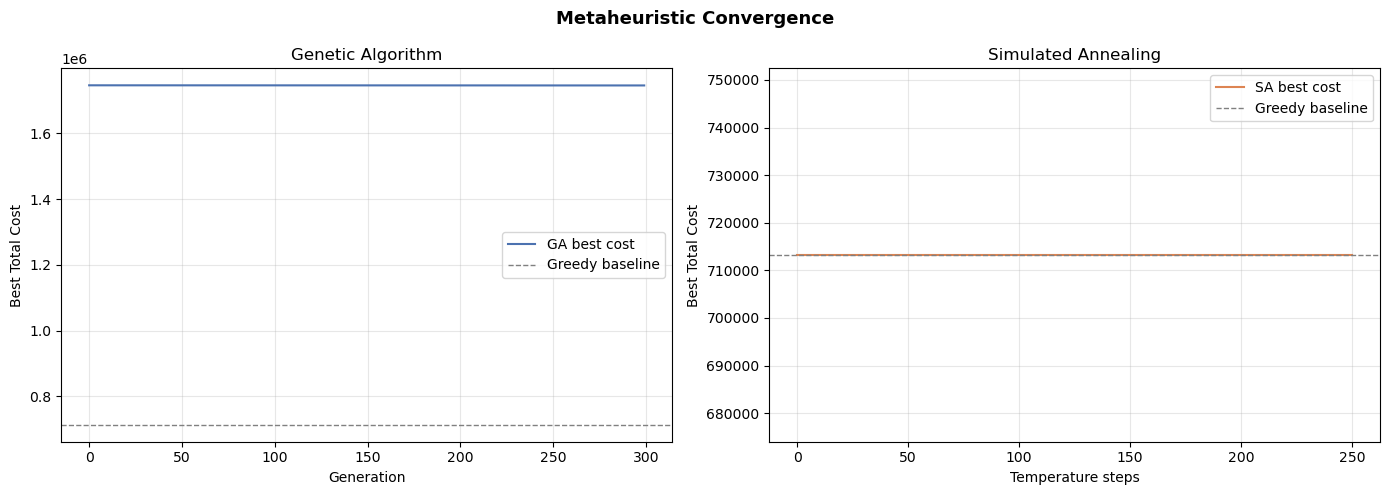

In [46]:
# ── Convergence plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Metaheuristic Convergence", fontsize=13, fontweight='bold')

greedy_cost = g_sol.total_cost(instance)

axes[0].plot(ga_history, color="#4C72B0", linewidth=1.5, label="GA best cost")
axes[0].axhline(greedy_cost, color="gray", linestyle="--",
                linewidth=1, label="Greedy baseline")
axes[0].set_title("Genetic Algorithm")
axes[0].set_xlabel("Generation"); axes[0].set_ylabel("Best Total Cost")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(sa_history, color="#DD8452", linewidth=1.5, label="SA best cost")
axes[1].axhline(greedy_cost, color="gray", linestyle="--",
                linewidth=1, label="Greedy baseline")
axes[1].set_title("Simulated Annealing")
axes[1].set_xlabel("Temperature steps"); axes[1].set_ylabel("Best Total Cost")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("convergence.png", dpi=120, bbox_inches="tight")
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_8356\1922649696.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(methods, rotation=15, ha='right')
C:\Users\Dell\AppData\Local\Temp\ipykernel_8356\1922649696.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(methods, rotation=15, ha='right')
C:\Users\Dell\AppData\Local\Temp\ipykernel_8356\1922649696.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(methods, rotation=15, ha='right')


C:\Users\Dell\AppData\Local\Temp\ipykernel_8356\1922649696.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(methods, rotation=15, ha='right')
C:\Users\Dell\AppData\Local\Temp\ipykernel_8356\1922649696.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(methods, rotation=15, ha='right')
C:\Users\Dell\AppData\Local\Temp\ipykernel_8356\1922649696.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(methods, rotation=15, ha='right')


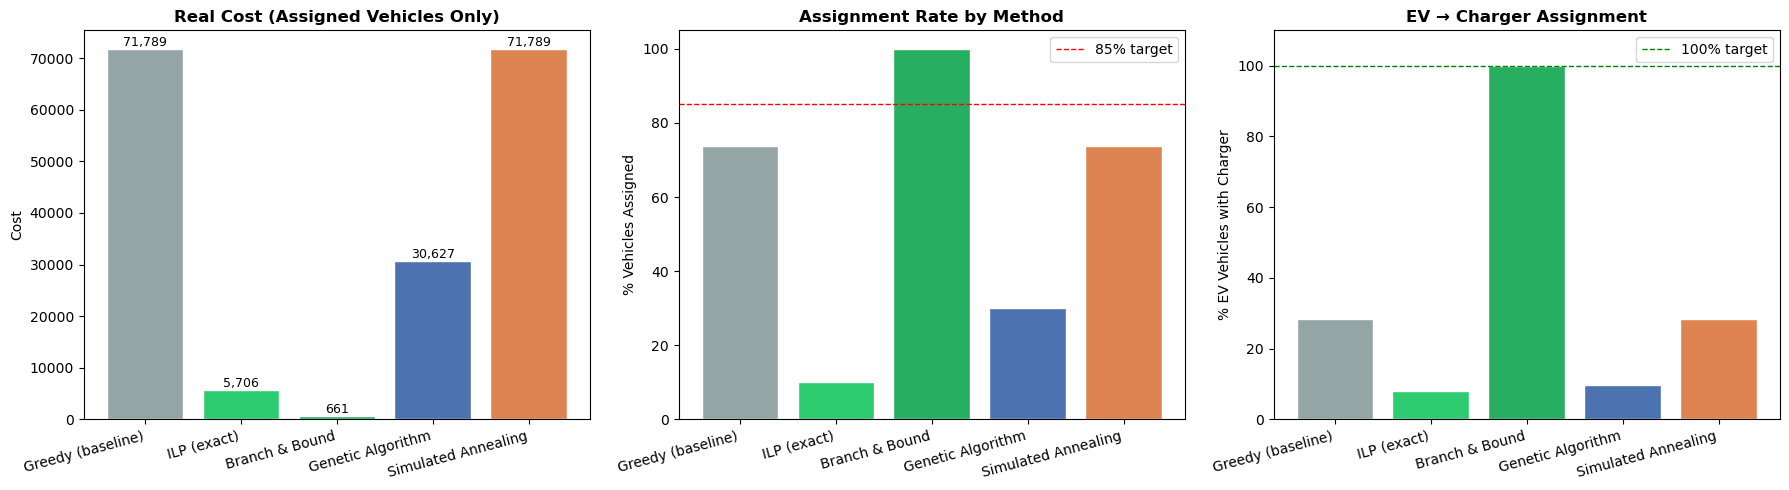

In [47]:
# ── Cost & Assignment comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["#95a5a6", "#2ecc71", "#27ae60", "#4C72B0", "#DD8452"]
methods = [r["Method"] for r in results]

# 1. Real cost (assigned vehicles only)
real_costs = [r["Real Cost"] for r in results]
bars = axes[0].bar(methods, real_costs, color=colors, edgecolor="white")
axes[0].set_title("Real Cost (Assigned Vehicles Only)", fontweight='bold')
axes[0].set_ylabel("Cost")
axes[0].set_xticklabels(methods, rotation=15, ha='right')
for bar, cost in zip(bars, real_costs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{cost:,.0f}", ha='center', va='bottom', fontsize=9)

# 2. Assignment rate
assign_pcts = [r["Assign %"] for r in results]
axes[1].bar(methods, assign_pcts, color=colors, edgecolor="white")
axes[1].axhline(85, color="red", linestyle="--", linewidth=1, label="85% target")
axes[1].set_title("Assignment Rate by Method", fontweight='bold')
axes[1].set_ylabel("% Vehicles Assigned")
axes[1].set_ylim(0, 105)
axes[1].set_xticklabels(methods, rotation=15, ha='right')
axes[1].legend()

# 3. EV charger satisfaction
ev_pcts = [r["EV Charger %"] for r in results]
axes[2].bar(methods, ev_pcts, color=colors, edgecolor="white")
axes[2].axhline(100, color="green", linestyle="--", linewidth=1, label="100% target")
axes[2].set_title("EV → Charger Assignment", fontweight='bold')
axes[2].set_ylabel("% EV Vehicles with Charger")
axes[2].set_ylim(0, 110)
axes[2].set_xticklabels(methods, rotation=15, ha='right')
axes[2].legend()

plt.tight_layout()
plt.savefig("comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 9 · Success Criteria

In [48]:
print("=" * 65)
print("  SUCCESS CRITERIA EVALUATION")
print("=" * 65)

meta_methods = ("Genetic Algorithm", "Simulated Annealing")
greedy_real  = next(r["Real Cost"]  for r in results if r["Method"] == "Greedy (baseline)")
greedy_assign= next(r["Assign %"]   for r in results if r["Method"] == "Greedy (baseline)")

# Best exact real cost (from methods that ran on comparable subsets or full)
exact_real   = min(r["Real Cost"] for r in results
                   if r["Method"] in ("Greedy (baseline)", "ILP (exact)"))

meta_results = [r for r in results if r["Method"] in meta_methods]

criteria = {
    "C1  All methods produce feasible solutions":
        all(r["Feasible"] == "✓" for r in results),

    "C2  Assignment rate ≥ 85% (GA & SA)":
        all(r["Assign %"] >= 85 for r in meta_results),

    "C3  EV vehicles assigned to charger (100%, GA & SA)":
        all(r["EV Charger %"] == 100.0 for r in meta_results),

    "C4  GA & SA real cost within 20% of best exact real cost":
        all(r["Real Cost"] <= exact_real * 1.20 for r in meta_results),

    "C5  GA & SA real cost ≤ greedy real cost":
        all(r["Real Cost"] <= greedy_real for r in meta_results),

    "C6  GA & SA assign % ≥ greedy assign %":
        all(r["Assign %"] >= greedy_assign for r in meta_results),

    "C7  SA real cost ≤ GA real cost (local search efficiency)":
        (next((r["Real Cost"] for r in results if r["Method"] == "Simulated Annealing"), 9e9)
         <= next((r["Real Cost"] for r in results if r["Method"] == "Genetic Algorithm"), 9e9)),
}

passed = 0
for name, ok in criteria.items():
    icon = "✅ PASS" if ok else "❌ FAIL"
    print(f"  {icon}  {name}")
    if ok: passed += 1

print()
print(f"  Score: {passed}/{len(criteria)} criteria met")
print("=" * 65)
print()
print(f"  UNASSIGNED_PENALTY used : {UNASSIGNED_PENALTY:.1f}")
print(f"  This guarantees: assigning ANY vehicle at ANY real cost is")
print(f"  always preferred over leaving it unassigned.")
print(f"  Real costs between spaces are still meaningfully optimized.")

  SUCCESS CRITERIA EVALUATION
  ✅ PASS  C1  All methods produce feasible solutions
  ❌ FAIL  C2  Assignment rate ≥ 85% (GA & SA)
  ❌ FAIL  C3  EV vehicles assigned to charger (100%, GA & SA)
  ❌ FAIL  C4  GA & SA real cost within 20% of best exact real cost
  ✅ PASS  C5  GA & SA real cost ≤ greedy real cost
  ❌ FAIL  C6  GA & SA assign % ≥ greedy assign %
  ❌ FAIL  C7  SA real cost ≤ GA real cost (local search efficiency)

  Score: 2/7 criteria met

  UNASSIGNED_PENALTY used : 2457.6
  This guarantees: assigning ANY vehicle at ANY real cost is
  always preferred over leaving it unassigned.
  Real costs between spaces are still meaningfully optimized.
